In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
    
from data.nuscenes_data import NuscenesData
from data.nuscenes_wrapper import SparseCLIP_Dataset
from nuscenes.nuscenes import NuScenes
from utils.visualize import SparseCLIP_visualize_open3d, SparseCLIP_visualize

from pathlib import Path
import torch

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Load dataset
data_path = Path("/home/ximeng/Dataset/nuscenes_full_v1_0/")
nusc = NuScenes(version='v1.0-mini', dataroot=data_path)
is_train = 1
pre_frame = 0
future_frame = 0
dataset = NuscenesData(nusc, is_train, pre_frame, future_frame)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.483 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [3]:
def sliding_window(seq, window_size, stride):
    L = len(seq)
    windows = []
    for start in range(0, L - window_size + 1, stride):
        windows.append(seq[start:start + window_size])
    if L % stride != 0 and L > 0:
        windows.append(seq[-window_size:])
    return windows

def pad_text_lidar_window(batch_pairs, window_size=32, stride=32):
    pts_dim = 1024
    all_windows = []

    # Create sliding windows for each sequence in the batch
    for pairs in batch_pairs:
        if len(pairs) == 0:
            continue
        windows = sliding_window(pairs, window_size, stride)
        all_windows.extend(windows)

    B_new = len(all_windows)
    padded_pts = torch.zeros(B_new, window_size, pts_dim, 3, dtype=torch.float32)
    mask = torch.zeros(B_new, window_size, dtype=torch.bool)
    padded_labels = [[''] * window_size for _ in range(B_new)]
    flat_labels = []

    for i, window in enumerate(all_windows):
        for j, (label, pts) in enumerate(window):
            if pts.shape != (pts_dim, 3):
                raise ValueError(f"Expected pts shape ({pts_dim}, 3), got {pts.shape}")
            padded_pts[i, j] = pts
            padded_labels[i][j] = label
            mask[i, j] = True
            flat_labels.append(label)

    return padded_pts, padded_labels, mask, flat_labels

In [4]:
def custom_collate_fn(batch):
    collated = {}
    keys = batch[0].keys()
    for k in keys:
        if k == 'all_bboxes':
            continue  # Skip collating 'all_bboxes'
        values = [b[k] for b in batch]
        if k == 'text_lidar_pair':
            values = [v for v in values if len(v) > 0]
            # Handle empty case
            if len(values) == 0:
                return None # Skip this batch
            # Use sliding window
            pts, labels, mask, flat_labels = pad_text_lidar_window(values, window_size=5, stride=5)
            collated['text_lidar_pts'] = pts
            collated['text_lidar_labels'] = labels
            collated['text_lidar_mask'] = mask
            collated['text_lidar_flat_labels'] = flat_labels
        else:
            # Use default collate for other keys
            try:
                collated[k] = torch.utils.data._utils.collate.default_collate(values)
            except Exception:
                collated[k] = values
    return collated

In [5]:
SparseCLIP_dataset = SparseCLIP_Dataset(dataset)
SparseCLIP_train_dataloader = torch.utils.data.DataLoader(SparseCLIP_dataset, batch_size=2, shuffle=True, collate_fn=custom_collate_fn)

In [6]:
sample0 = SparseCLIP_dataset[10]
print(sample0['all_bboxes'])

[{'sample_token': 'afe61fa5fb114c1cb7448c0cb6830019', 'instance_token': 'ca5b3ca5aea745ee8fe12b0f74d77f8e', 'bbox': [21.40199720849384, -13.611841660184473, 0.8697786407800455, 1.743, 4.98, 1.689, 3.0571133353342383], 'category': 'vehicle.car'}, {'sample_token': '328e782633734d7391ef39ad8a489c37', 'instance_token': '293693af6bb54699a63dfb6d8db3504f', 'bbox': [-13.9972251175655, -62.38257906420218, 3.188537959595848, 1.865, 4.425, 1.547, -0.006131095493153399], 'category': 'vehicle.car'}, {'sample_token': 'f1533b8ab13d4175b49371c2c3131512', 'instance_token': '6dafc154a9ef43ff8fd680620dc90433', 'bbox': [-10.96894573951814, -15.701870255007456, 0.9000792906055932, 1.955, 5.104, 1.645, -0.0999774496900525], 'category': 'vehicle.car'}, {'sample_token': '4d15e0753b594029983746f99bc600d6', 'instance_token': '4591a9f392774001a2cf523286505ac9', 'bbox': [6.685243782554202, 5.423839182595009, 1.1346492732232156, 0.583, 0.485, 1.68, -1.7412501716540703], 'category': 'human.pedestrian.adult'}, {'sa

In [7]:
for b in sample0['all_bboxes']:
    print(b['bbox'])
    break

[21.40199720849384, -13.611841660184473, 0.8697786407800455, 1.743, 4.98, 1.689, 3.0571133353342383]


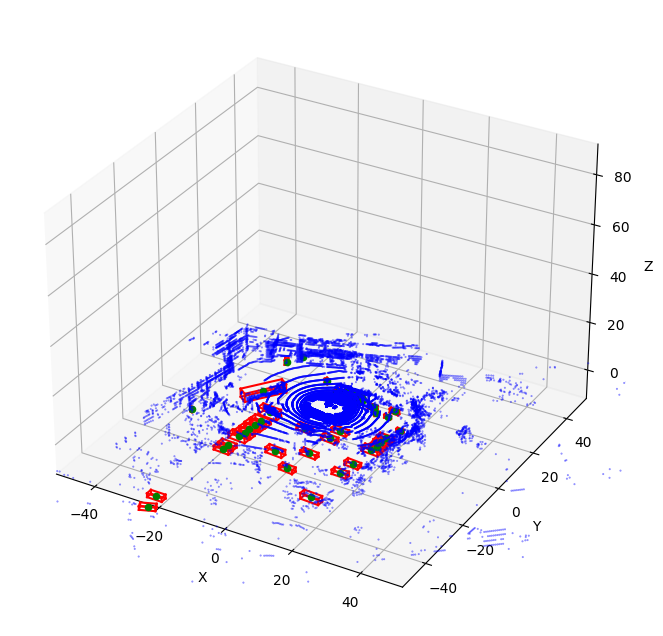

In [8]:
SparseCLIP_visualize(sample0)

In [9]:
# SparseCLIP_visualize_open3d(sample0, 4)

In [10]:
# for sample in SparseCLIP_train_dataloader:
#     text_lidar_pair = sample['text_lidar_pts']
#     text_lidar_labels = sample['text_lidar_labels']
#     text_lidar_mask = sample['text_lidar_mask']
#     text_lidar_flat_labels = sample['text_lidar_flat_labels']
#     break  # Just to test the data loading
# print(text_lidar_pair.shape)
# print(text_lidar_labels)
# print(text_lidar_mask)
# print(text_lidar_flat_labels)

In [11]:
sample0['til_triplet'][0]

('car',
 <PIL.Image.Image image mode=RGB size=395x133>,
 tensor([[ -8.5329, -16.7375,   0.1833],
         [ -8.7058, -16.8254,   0.1719],
         [ -8.9940, -16.8713,   0.1616],
         [ -9.3189, -16.7573,   0.1638],
         [ -8.5980, -15.5762,   0.7072],
         [ -8.5548, -15.2930,   0.3071],
         [ -8.6624, -15.4808,   0.7127],
         [ -8.5952, -15.1626,   0.3171],
         [ -8.6816, -15.3141,   0.7233],
         [ -8.6483, -15.0542,   0.3250],
         [ -8.7519, -15.0263,   0.3247],
         [ -8.7916, -15.1009,   0.7356],
         [ -8.9226, -15.1015,   0.3139],
         [ -8.8642, -15.0234,   0.7396],
         [ -8.9732, -14.9901,   0.3219],
         [ -8.9625, -14.9857,   0.7407],
         [ -9.1728, -15.1045,   0.3069],
         [ -9.0655, -14.9490,   0.7416],
         [ -9.1965, -14.9474,   0.3193],
         [ -9.2203, -14.9945,   0.7364],
         [ -9.3216, -14.9471,   0.3159],
         [ -9.4500, -15.1477,   0.7233],
         [ -9.4124, -14.9074,   0.7391],
 